# Strategy Lab 01 - Trend-following strategy

这篇只做一件事：用 DeTime 分解出来的 `trend` 直接产生交易信号。

策略逻辑：

1. `trend_slope > 0` 且 `trend_strength` 足够强，说明进入上涨趋势状态。
2. `cycle_position` 不在过热区，避免在周期顶部追进去。
3. `residual_abs_z` 不过大，避免追到结构外的异常拉伸。
4. 如果有成交量分解，则用 `volume_trend_slope / volume_residual_z` 确认参与度。
5. 信号在第 t 根 bar 结束后生成，回测用下一根 bar 的开盘价成交。

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display
from quant_trading.data import load_sample_goog_ohlcv
from quant_trading.decomposition_features import walkforward_price_volume_features
from quant_trading.strategy_lab import (
    TrendFollowingConfig,
    OscillationReversionConfig,
    backtest_signal_set,
    execution_price_panel,
    decomposition_trend_following_signals,
    decomposition_oscillation_reversion_signals,
    plot_signal_analysis,
    stats_table,
)
from quant_trading.strategy_baselines import (
    buy_and_hold_weights,
    dual_moving_average_weights,
    bollinger_mean_reversion_weights,
)
from quant_trading.strategy_lab import backtest_target_weights_next_bar

CHART_DIR = Path("examples/quant_trading/reports/strategy_lab/charts")

In [2]:
ohlcv = load_sample_goog_ohlcv(trim_start="2014-01-01")
symbol = "GOOG"
close = ohlcv["Close"].rename(symbol).to_frame()
volume = ohlcv["Volume"].rename(symbol).to_frame()
execution_prices = execution_price_panel(ohlcv, field="Open", next_bar=True)
execution_prices.columns = [symbol]

features = walkforward_price_volume_features(
    close, volume, method="STL", period=126, train_window=504, step=5, z_window=63
)
list(features)[:8]


['trend',
 'cycle',
 'residual',
 'trend_slope',
 'trend_acceleration',
 'trend_strength',
 'trend_gap',
 'cycle_z']

In [3]:
signal = decomposition_trend_following_signals(
    close,
    features,
    config=TrendFollowingConfig(
        entry_trend_strength=0.15,
        exit_trend_strength=0.02,
        max_entry_cycle_position=1.25,
        max_entry_residual_abs_z=2.5,
        use_volume_confirmation=True,
        allow_short=False,
    ),
    name="detime_STL_trend_following",
)

bt = backtest_signal_set(
    close, signal, execution_prices=execution_prices, fee_bps=5, slippage_bps=2, periods_per_year=252
)

baselines = {
    "buy_hold": buy_and_hold_weights(close),
    "classic_sma_20_100": dual_moving_average_weights(close, fast=20, slow=100),
}
results = {signal.name: bt}
for name, weights in baselines.items():
    results[name] = backtest_target_weights_next_bar(
        close, weights, execution_prices=execution_prices, fee_bps=5, slippage_bps=2, periods_per_year=252, name=name
    )

stats_table(results)

,strategy,total_return,cagr,sharpe,max_drawdown,calmar,volatility,hit_rate,trade_win_rate,average_trade_directional_return,orders,round_trips,median_bars_held,average_turnover,average_gross_exposure,fee_bps,slippage_bps,periods_per_year,execution_model
1,buy_hold,0.887479,0.172116,0.799165,-0.192787,0.892778,0.232171,0.524802,NaN,NaN,1.0,0.0,NaN,0.000000,1.000000,5.0,2.0,252.0,signal_on_bar_t_fill_next_bar_open_or_proxy
2,classic_sma_20_100,0.010232,0.002548,0.107019,-0.297157,0.008576,0.187310,0.332341,0.25,-0.002942,17.0,8.0,67.0,0.016865,0.630952,5.0,2.0,252.0,signal_on_bar_t_fill_next_bar_open_or_proxy
0,detime_STL_trend_following,-0.006633,-0.001663,-0.213044,-0.018183,-0.091433,0.007671,0.002976,0.00,-0.018574,2.0,1.0,5.0,0.000678,0.001696,5.0,2.0,252.0,signal_on_bar_t_fill_next_bar_open_or_proxy


In [4]:
bt.orders.tail(10)

,asset,signal_date,fill_date,action,previous_weight,new_weight,delta_weight,fill_price
0,GOOG,2016-01-08,2016-01-11,buy,0.000000,0.341871,0.341871,716.609985
1,GOOG,2016-01-15,2016-01-19,sell,0.341871,0.000000,-0.341871,703.299988


In [5]:
bt.trades.tail(10)

,asset,side,entry_signal_date,entry_fill_date,exit_signal_date,exit_fill_date,entry_price,exit_price,bars_held,entry_weight,directional_return,approx_weighted_return_after_cost
0,GOOG,long,2016-01-08,2016-01-11,2016-01-15,2016-01-19,716.609985,703.299988,5,0.341871,-0.018574,-0.006589


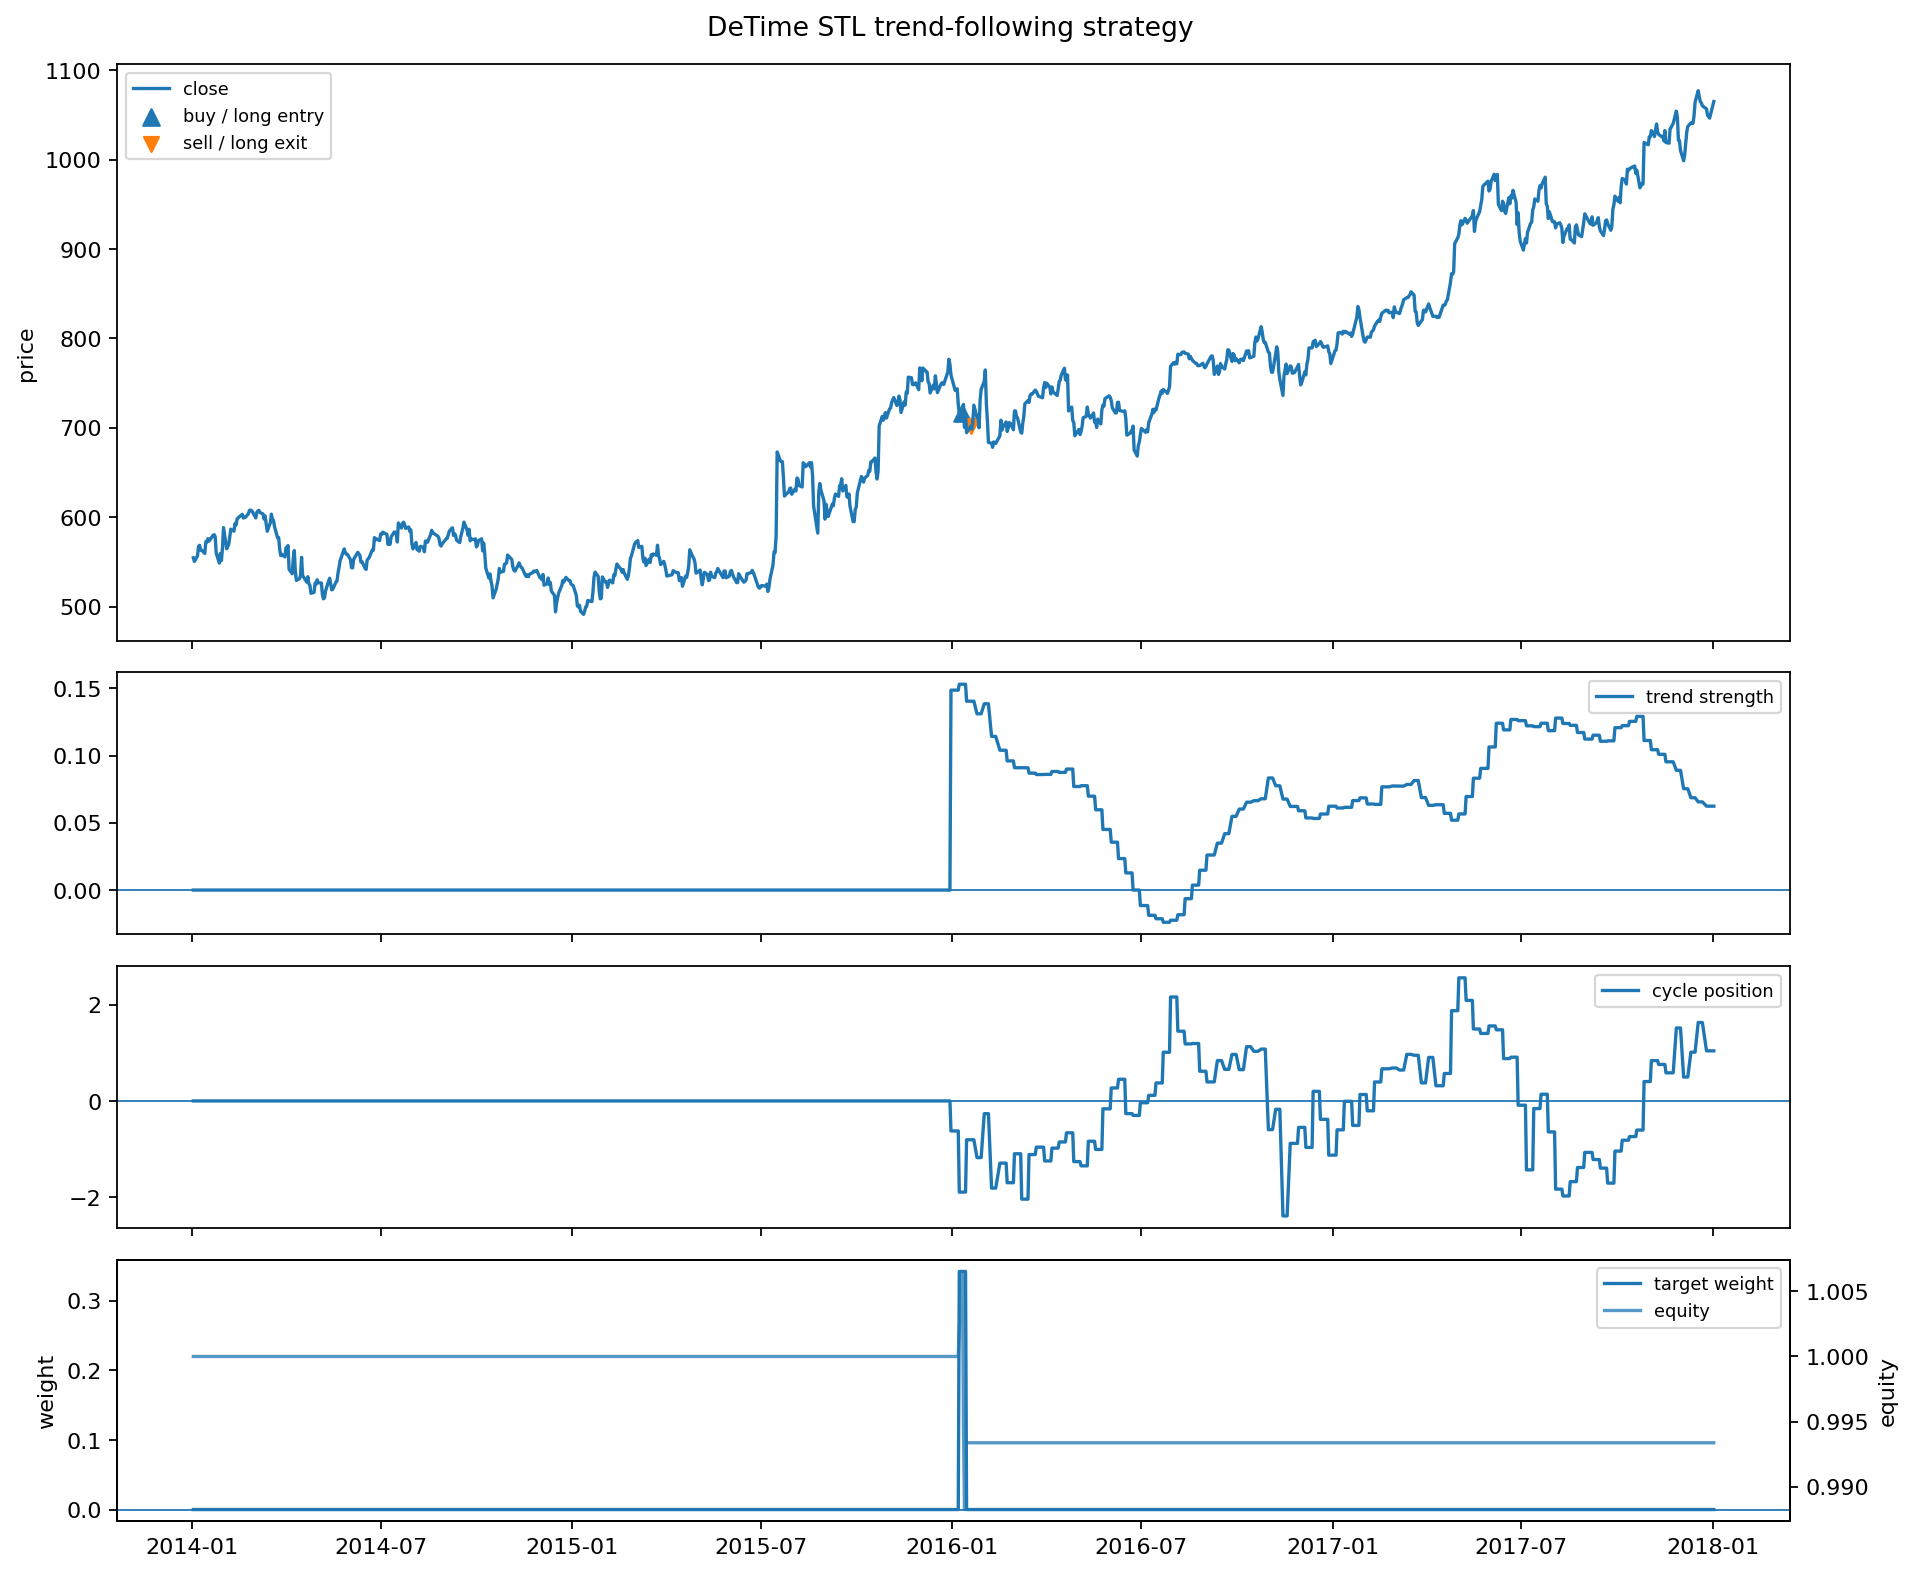

'examples/quant_trading/reports/strategy_lab/charts/notebook_01_trend_following.png'

In [6]:
out = CHART_DIR / "notebook_01_trend_following.png"
plot_signal_analysis(ohlcv, signal, bt, asset=symbol, output_path=out, title="DeTime STL trend-following strategy")
display(Image(filename=str(out)))
out.as_posix()